# Setup

In [1]:
# Cell 1
!pip install ultralytics
%matplotlib inline

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.4 MB/s eta 0:00:00


In [2]:
# Cell 2
import os
import zipfile
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
# Cell 3
# Current working directory
BASE_DIR = os.getcwd()

zip_file = os.path.join(
    BASE_DIR,
    "Bangladeshi Bank Note Detection.v1i.yolov11.zip"
)

extract_dir = os.path.join(BASE_DIR, "Bangladeshi-Bank-Note-Detection")

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("✅ Dataset unzipped successfully")

✅ Dataset unzipped successfully


In [5]:
# Cell 4
BASE_DIR = os.getcwd()

DATASET_DIR = os.path.join(BASE_DIR, "Bangladeshi-Bank-Note-Detection")
DATA_YAML = os.path.join(DATASET_DIR, "data.yaml")
TEST_IMAGES_DIR = os.path.join(DATASET_DIR, "test", "images")

# Allowed image extensions
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

test_images = [
    f for f in os.listdir(TEST_IMAGES_DIR)
    if f.lower().endswith(IMAGE_EXTS)
]

if not test_images:
    raise FileNotFoundError("❌ No test images found in test/images directory")

TEST_IMAGE = os.path.join(TEST_IMAGES_DIR, test_images[0])

print(f"✅ Using test image: {TEST_IMAGE}")

✅ Using test image: /content/Bangladeshi-Bank-Note-Detection/test/images/500-11342-_png.rf.056d1cf5c5c49d653f5fb2fce55d27c2.jpg


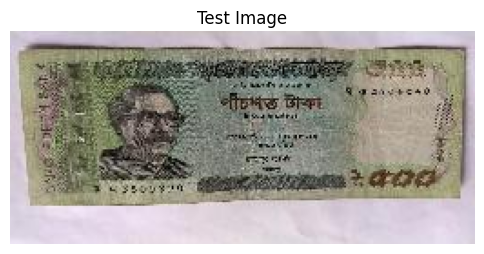

In [6]:
# Cell 5
# Load image
img = Image.open(TEST_IMAGE)

# Show image
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Test Image")
plt.show()

# Load Pre-trained YOLO Model

In [7]:
# Cell 6
pretrained_model = YOLO('yolo11n.pt') # nano model for quick demo

# TEST ON Taka IMAGE

In [8]:
# Cell 7
print("🔍 Inference using pretrained YOLO11n model...")

pretrained_model.predict(
    source=TEST_IMAGE,
    save=True,
    conf=0.25,
    name="pretrained_inference"
)

🔍 Inference using pretrained YOLO11n model...

image 1/1 /content/Bangladeshi-Bank-Note-Detection/test/images/500-11342-_png.rf.056d1cf5c5c49d653f5fb2fce55d27c2.jpg: 320x640 (no detections), 8.5ms
Speed: 71.2ms preprocess, 8.5ms inference, 5.7ms postprocess per image at shape (1, 3, 320, 640)
Results saved to /content/runs/detect/pretrained_inference


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 

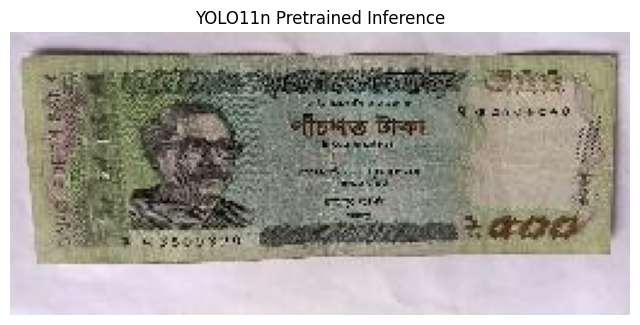

In [9]:
# Cell 8
# YOLO saves results here by default
OUTPUT_DIR = os.path.join(os.getcwd(), "runs", "detect", "pretrained_inference")

# The inference image file (same as TEST_IMAGE name)
inferred_image_path = os.path.join(OUTPUT_DIR, os.listdir(OUTPUT_DIR)[0])

# Load and display
img = Image.open(inferred_image_path)

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.title("YOLO11n Pretrained Inference")
plt.show()

# Fine-tuning YOLO

In [10]:
# Cell 9
BASE_DIR = os.getcwd()

data_yaml = os.path.join(
    BASE_DIR,
    "Bangladeshi-Bank-Note-Detection",
    "data.yaml"
)

# চেক করা হচ্ছে আগে অর্ধেক ট্রেনিং হওয়া কোনো ফাইল আছে কি না
last_weight_path = os.path.join(
    BASE_DIR,
    "runs",
    "detect",
    "Bangladeshi-Bank-Note-Detector",
    "weights",
    "last.pt"
)

if os.path.exists(last_weight_path):
    print("🔄 Checkpoint found! Resuming training from the last saved epoch...")
    # আগের সেভ হওয়া মডেল লোড করে ঠিক যেখান থেকে বন্ধ হয়েছিল সেখান থেকে শুরু হবে
    model = YOLO(last_weight_path)
    model.train(resume=True)
else:
    print("🚀 No checkpoint found. Starting training from scratch...")
    # Load pretrained model
    model = YOLO("yolo11n.pt")

    # Train (নতুন করে শুরু করার জন্য)
    model.train(
        data=data_yaml,
        epochs=100,         # মোট ১০০ ইপক দেওয়া হলো
        imgsz=640,
        batch=16,
        name="Bangladeshi-Bank-Note-Detector",
        device=0,           # remove or set to "cpu" if no GPU
        patience=10         # ১০ ইপক পর্যন্ত উন্নতি না হলে অটোমেটিক বন্ধ হয়ে যাবে
    )

🚀 No checkpoint found. Starting training from scratch...
Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Bangladeshi-Bank-Note-Detection/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, mo

# EVALUATION


image 1/1 /content/Bangladeshi-Bank-Note-Detection/test/images/500-11342-_png.rf.056d1cf5c5c49d653f5fb2fce55d27c2.jpg: 320x640 1 500 BDT, 10.5ms
Speed: 1.7ms preprocess, 10.5ms inference, 1.4ms postprocess per image at shape (1, 3, 320, 640)
Results saved to /content/runs/detect/trained_inference


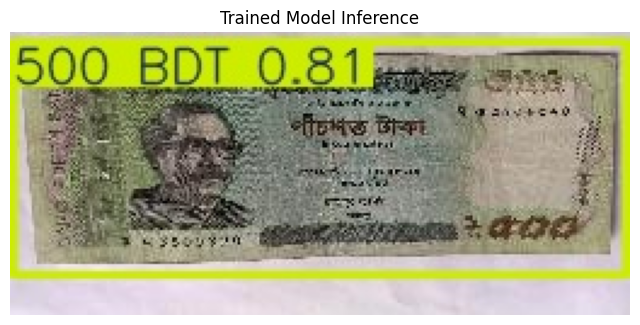

In [11]:
# Cell 10
BASE_DIR = os.getcwd()

# Path to trained model
trained_model_path = os.path.join(
    BASE_DIR,
    "runs",
    "detect",
    "Bangladeshi-Bank-Note-Detector",
    "weights",
    "best.pt"
)

# Load trained model
trained_model = YOLO(trained_model_path)

# Path to test image (same one as before)
TEST_IMAGES_DIR = os.path.join(BASE_DIR, "Bangladeshi-Bank-Note-Detection", "test", "images")
TEST_IMAGE = os.path.join(TEST_IMAGES_DIR, os.listdir(TEST_IMAGES_DIR)[0])

# Run inference
results = trained_model.predict(
    source=TEST_IMAGE,
    save=True,          # saves output in runs/detect/
    conf=0.25,
    name="trained_inference"
)

# Display the inference image inline
OUTPUT_DIR = os.path.join(BASE_DIR, "runs", "detect", "trained_inference")
inferred_image_path = os.path.join(OUTPUT_DIR, os.listdir(OUTPUT_DIR)[0])

img = Image.open(inferred_image_path)
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Trained Model Inference")
plt.show()